In [280]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as mp

# Task 2: Data Aquisition & Initial Visualization

In [281]:
#Load data

#please note that this is the only path I could get to work on my Mac! Please change your path as needed
duchesne = pd.read_csv("/uufs/chpc.utah.edu/common/home/u1600917/Hydroinformatics/Homework1/data/09277500_1980_2020.csv")
duchesne = duchesne.dropna(subset=["USGS_flow"]).drop(columns=['variable','USGS_ID','measurement_unit','qualifiers','series'])
duchesne["Datetime"] = pd.to_datetime(duchesne["Datetime"])


moon_reservoir = pd.read_csv("/uufs/chpc.utah.edu/common/home/u1600917/Hydroinformatics/Homework1/data/09291000_1980_2020.csv")
moon_reservoir = moon_reservoir.dropna(subset=["USGS_flow"]).drop(columns=['variable','USGS_ID','measurement_unit','qualifiers','series'])
moon_reservoir["Datetime"] = pd.to_datetime(moon_reservoir["Datetime"])

weber_headwater = pd.read_csv("/uufs/chpc.utah.edu/common/home/u1600917/Hydroinformatics/Homework1/data/10128500_1980_2020.csv")
weber_headwater = weber_headwater.dropna(subset=["USGS_flow"]).drop(columns=['variable','USGS_ID','measurement_unit','qualifiers','series'])
weber_headwater["Datetime"] = pd.to_datetime(weber_headwater["Datetime"])

provo = pd.read_csv("/uufs/chpc.utah.edu/common/home/u1600917/Hydroinformatics/Homework1/data/10154200_1980_2020.csv")
provo = provo.dropna(subset=["USGS_flow"]).drop(columns=['variable','USGS_ID','measurement_unit','qualifiers','series'])
provo["Datetime"] = pd.to_datetime(provo["Datetime"])


In [282]:
#process the data, I chose to perform 2014,2015,2016,2017,2018, and 2019 as my 6 years
#note that I have gone back to convert my data into MGD here, as the later tasks were hard to analyze in cfs

duchesne = duchesne.loc[duchesne.index[duchesne["Datetime"].dt.year == 2014].min():duchesne.index[duchesne["Datetime"].dt.year == 2019].max()]
duchesne["USGS_flow"] = duchesne["USGS_flow"]*0.646

moon_reservoir = moon_reservoir.loc[moon_reservoir.index[moon_reservoir["Datetime"].dt.year == 2014].min():moon_reservoir.index[moon_reservoir["Datetime"].dt.year == 2019].max()]
moon_reservoir["USGS_flow"] = moon_reservoir["USGS_flow"]*0.646

weber_headwater = weber_headwater.loc[weber_headwater.index[weber_headwater["Datetime"].dt.year == 2014].min():weber_headwater.index[weber_headwater["Datetime"].dt.year == 2019].max()]
weber_headwater["USGS_flow"] = weber_headwater["USGS_flow"]*0.646

provo = provo.loc[provo.index[provo["Datetime"].dt.year == 2014].min():provo.index[provo["Datetime"].dt.year == 2019].max()]
provo["USGS_flow"] = provo["USGS_flow"]*0.646

streamflow = duchesne.merge(moon_reservoir.merge(weber_headwater.merge(provo,how="outer",on="Datetime",sort=True,suffixes = ['_weber','_provo']),how="outer",on="Datetime",sort=True),how="outer",on="Datetime",sort=True,suffixes=['_duch','_moon'])
streamflow.set_index("Datetime",inplace=True) #Note that this set_index requires to hit "run all" or the code doesn't work

#Rename columns to be accurate with data
streamflow = streamflow.rename(columns={"USGS_flow_duch":"Duchesne Site","USGS_flow_moon":"Moon Lake Reservoir", "USGS_flow_provo":"Provo Site","USGS_flow_weber":"Weber Headwater Catchment"})

array([[<Axes: xlabel='Datetime', ylabel='Streamflow (MGD)'>,
        <Axes: xlabel='Datetime', ylabel='Streamflow (MGD)'>],
       [<Axes: xlabel='Datetime', ylabel='Streamflow (MGD)'>,
        <Axes: xlabel='Datetime', ylabel='Streamflow (MGD)'>]],
      dtype=object)

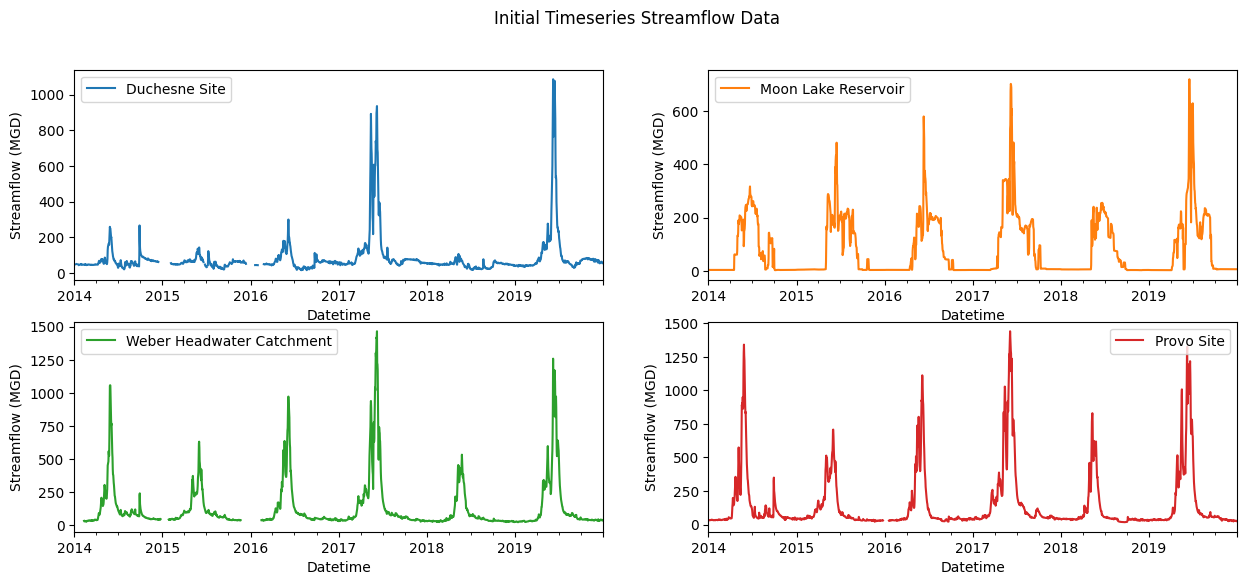

In [283]:
#Exploratory Data Analysis
streamflow.plot(title="Initial Timeseries Streamflow Data",
                figsize = (15,6),
                subplots=True,
                layout=(2,2),
                sharex=False,
                ylabel="Streamflow (MGD)")

# Task 3: Temporal Resampling & Statistical Aggregation

In [284]:
#raw daily
daily = streamflow
#weekly mean
weekly = streamflow.resample('W').mean()
#monthly total
monthly = streamflow.resample('ME').sum()

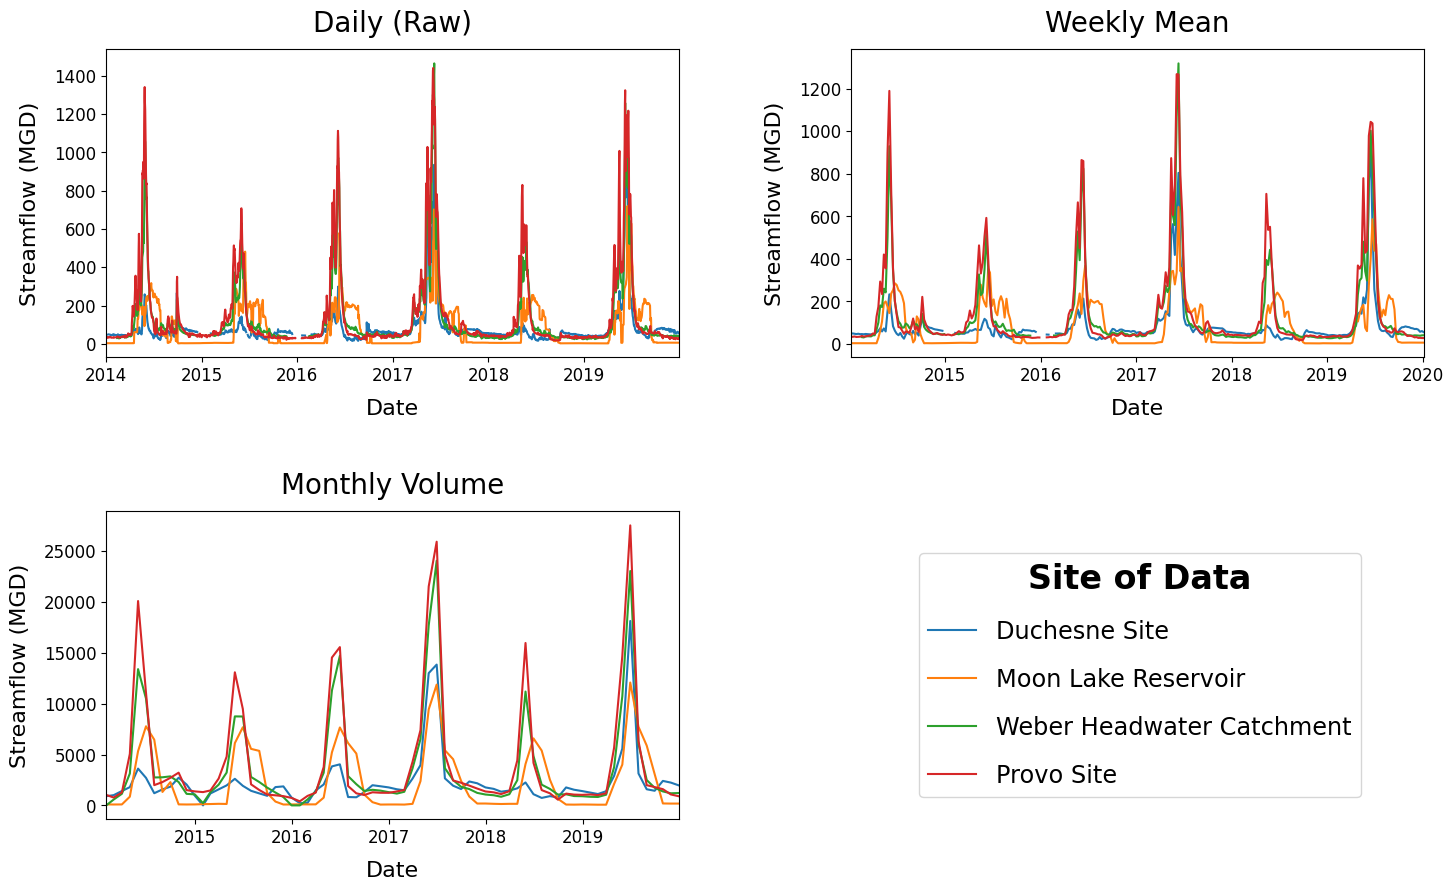

In [285]:
#Visualization
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(17,10))

plotA = ax[0,0]
plotB = ax[0,1]
plotC = ax[1,0]
fig.delaxes(ax[1,1])

#daily plot
plotA.plot(daily)
plotA.set_title("Daily (Raw)",fontsize = 20,y=1.03)
plotA.set_xlabel("Date",fontsize = 16,labelpad=10)
plotA.set_ylabel("Streamflow (MGD)", fontsize = 16,labelpad=10)
plotA.set_xlim(daily.index.min(),daily.index.max())
plotA.tick_params(axis='both', labelsize=12)


#weekly plot
plotB.plot(weekly)
plotB.set_title("Weekly Mean",fontsize = 20,y=1.03)
plotB.set_xlabel("Date",fontsize = 16,labelpad=10)
plotB.set_ylabel("Streamflow (MGD)", fontsize = 16,labelpad=10)
plotB.set_xlim(weekly.index.min(),weekly.index.max())
plotB.tick_params(axis='both', labelsize=12)

#monthly plot
plotC.plot(monthly)
plotC.set_title("Monthly Volume",fontsize = 20,y=1.03)
plotC.set_xlabel("Date",fontsize = 16,labelpad=10)
plotC.set_ylabel("Streamflow (MGD)", fontsize = 16,labelpad=10)
plotC.set_xlim(monthly.index.min(),monthly.index.max())
plotC.tick_params(axis='both', labelsize=12)

plotD.set_axis_off()

#Panel D -> legend
plt.subplots_adjust(hspace=0.5, wspace=0.3)
fig.legend(daily.columns.values, 
           loc='lower right',
           bbox_to_anchor=(0.87, 0.12),
           fontsize = 'xx-large',
           title = "Site of Data",
           labelspacing = 1,
           title_fontproperties = {'weight':'bold','size':24}
           )
plt.show()